<a href="https://colab.research.google.com/github/maryreginaf15/Programacao-Ia-Generativa/blob/main/yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalar dependências
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


[SISTEMA] Carregar os epsso da Rede Neural (YOLOv8) ...

--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---
 -> Detecção: CAR | Confiança:  87.6%
 -> Detecção: CAR | Confiança:  83.7%
 -> Detecção: CAR | Confiança:  80.6%
 -> Detecção: CAR | Confiança:  80.3%
 -> Detecção: CAR | Confiança:  78.7%
 -> Detecção: CAR | Confiança:  78.7%
 -> Detecção: CAR | Confiança:  71.5%
 -> Detecção: CAR | Confiança:  71.2%
 -> Detecção: CAR | Confiança:  69.1%
 -> Detecção: CAR | Confiança:  62.2%
 -> Detecção: CAR | Confiança:  58.7%
 -> Detecção: CAR | Confiança:  55.1%
 -> Detecção: PERSON | Confiança:  51.1%
 -> Detecção: CAR | Confiança:  50.8%
 -> Detecção: TRUCK | Confiança:  50.3%
 -> Detecção: CAR | Confiança:  48.5%
 -> Detecção: CAR | Confiança:  47.7%
 -> Detecção: CAR | Confiança:  46.3%
 -> Detecção: MOTORCYCLE | Confiança:  45.8%
 -> Detecção: PERSON | Confiança:  43.3%
 -> Detecção: CAR | Confiança:  39.7%
 -> Detecção: CAR | Confiança:  39.6%
 -> Detecção: TRUCK | Confiança:  38.2%
 

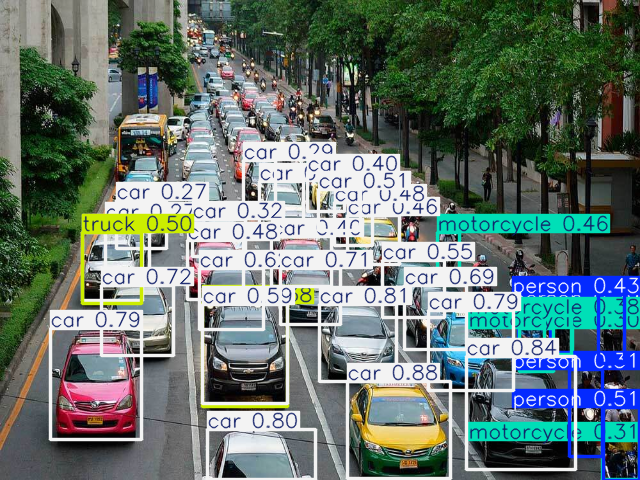

In [10]:
#DETECÇÃO DE MÚLTIPLOS OBJETOS COM YOLO

import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1 Carregar o modelo YOLOv8 pré-treinado
print("[SISTEMA] Carregar os epsso da Rede Neural (YOLOv8) ...")
modelo_yolo = YOLO('yolov8n.pt')

# 2 Carregar a imagem estática
imagem_bruta = cv2.imread('movimento.jpg')

# 3 Redimensionar para o tamanho padrão
imagem_redimensionada = cv2.resize(imagem_bruta, (640, 480))

# 4 Passar a imagem tratada pela inteligência  do YOLOv8 e gerar o mapa visual
#com as Bounding Boxes (Caixas Delimitadoras) automaticas.
resultados = modelo_yolo(imagem_redimensionada, verbose=False)

# 5 O METODO .PLOT() aciona internamente o openCV para:
# - Ler as coordenadas invisiveis gerada pela IA
# - Desenhar os retângulos coloridos de forma automática
# - Escrever o nome da classe (ex: 'peson', 'chair', 'cell phone') e a confiança


imagem_final_ia = resultados[0].plot()

#6 Imprimir os objetos detectados pela IA
print("\n--- OBJETOS DETECTADOS NO BANCO DE DADOS DA IA ---")

for caixa in resultados[0].boxes:
    # Extrai o ID da classe e traduz para o nome do objeto
    classe_id = int(caixa.cls[0])
    nome_objeto = modelo_yolo.names[classe_id]

    # Extrair o score de confiança (probabilidade matemática de acesso da IA)
    confianca = float(caixa.conf[0]) * 100

    print(f" -> Detecção: {nome_objeto.upper()} | Confiança: {confianca: .1f}%")

# 7 Extrair o painel visual final para validação
print("\n -- Resultado do Monitoramento por Inteligência Artificial --")
cv2_imshow(imagem_final_ia)




